# Carbon Cycle Simulation and Numerical Analysis

This notebook provides a complete simulation of the global carbon cycle starting from 1850.$\newline$
It tracks the exchange of carbon across different Earth system reservoirs (atmosphere, ocean, land, fossil fuels) and compares several numerical integration methods for solving the resulting differential equations.

## Imports and global parameters

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import solve_ivp

In [3]:
BASE_DIR = Path().resolve()

# Initial conditions in Gt of carbon (1850 baseline)
Atmosphere_Initial      = 750
CarbonateRock_Initial   = 100_000_000
DeepOcean_Initial       = 38_000
FossilFuel_Initial      = 7_500
Plant_Initial           = 560
Soil_Initial            = 1_500
SurfaceOcean_Initial    = 890
VegLandArea_percent_Initial = 100

x0 = np.array([
    Atmosphere_Initial, CarbonateRock_Initial, DeepOcean_Initial,
    FossilFuel_Initial, Plant_Initial, Soil_Initial,
    SurfaceOcean_Initial, VegLandArea_percent_Initial
], dtype=float)

STATE_LABELS = ['atm', 'rock', 'deep', 'fossil', 'plant', 'soil', 'surf', 'veg']

# Physical constants
Alk        = 2.222446077610055   # alkalinity 
Kao        = 0.278               # air-sea gas exchange coefficient
SurfOcVol  = 0.0362              # surface ocean volume 
Deforestation = 1.5              # land-use flux

# Default scenario
SCENARIO = "BAU"

def _fmt(v):
    if v == 0:
        return '0e0'
    s = f'{float(v):.3e}'
    m, e = s.split('e')
    return f'{m.rstrip("0").rstrip(".").replace(".", "p")}e{int(e)}'

def get_output_dir(subdir):
    p = BASE_DIR / subdir
    p.mkdir(parents=True, exist_ok=True)
    return p

## Physical Model Definition
This section defines the diagnostic variables such as temperature anomalies, ocean carbonate chemistry, and the differential equations governing the fluxes between reservoirs.

The model writes:
$$ f(t, x) = A_{lin}x + b + g(x,t) $$

Where $A_{lin}$ is the linear transition matrix defined by constant proportional transfer rates between reservoirs :
$$ A_{lin} = \begin{bmatrix} 
-\alpha_A K_{ao} & 0 & 0 & 0 & k_p & k_s & 0 & 0 \\
0 & 0 & k_{sed} & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & -(k_{sed}+k_{up}) & 0 & 0 & 0 & k_{down} & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & -2k_p & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & k_p & -k_s & 0 & 0 \\
\alpha_A K_{ao} & 0 & k_{up} & 0 & 0 & 0 & -k_{down} & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 
\end{bmatrix} $$

The vector $b$ incorporates constant forcing terms like volcanism ($\nu$) and deforestation parameters ($\beta$, $\delta $):
$$ b = \begin{bmatrix} \nu + \beta \\ -\nu \\ 0 \\ 0 \\ 2\beta \\ \beta \\ 0 \\ -\delta \end{bmatrix} $$

The nonlinear component $g(x,t)$ encapsulates the complex, state-dependent fluxes
$$ g(x,t) = \begin{bmatrix} 
\nu_F(t, F) + K_{ao} pCO_2^{oc}(A, O) - \Phi(A,V) \\
0 \\
0 \\
-\nu_F(t, F) \\
\Phi(A, V) \\
0 \\
-K_{ao} pCO_2^{oc}(A, O) \\
0
\end{bmatrix} $$

## Implementation of the Carbon Cycle Model

In [4]:
def AtmCO2(A):
    return A * (280 / Atmosphere_Initial)

def GlobalTemp(co2_ppm):
    return 15 + (co2_ppm - 280) * 0.01

def CO2Effect(co2_ppm):
    return 1.5 * (co2_ppm - 40) / (co2_ppm + 80)

def TempEffect(T):
    return ((60 - T) * (T + 15)) / ((37.5) ** 2) / 0.96

def WaterTemp(T):
    return 273 + T

def SurfCConc(O):
    return (O / 12_000) / SurfOcVol

def Kcarb(Tw):
    return 5.75e-4 + 6e-6 * (Tw - 278)

def KCO2(Tw):
    return 0.035 + 0.0019 * (Tw - 278)

def HCO3(kc, sc):
    denom = 1 - 4 * kc
    if abs(denom) < 1e-10:
        return sc / 2
    disc = sc**2 - Alk * (2*sc - Alk) * (1 - 4*kc)
    return (sc - np.sqrt(max(disc, 0))) / denom

def CO3(hco3):
    return (Alk - hco3) / 2

def pCO2Oc(kco2, hco3, co3):
    return 280 * kco2 * (hco3**2 / co3)

_FF_DATA = np.array([
    [1850, 0.00], [1875, 0.30], [1900, 0.60], [1925, 1.35],
    [1950, 2.85], [1975, 4.95], [2000, 7.20], [2025, 10.05],
    [2050, 14.85], [2075, 20.70], [2100, 30.00]
])

def FossilFuelsCombustion(t):
    if SCENARIO == "ACTION" and t > 2030:
        return 0.0
    if t >= _FF_DATA[-1, 0]:
        return _FF_DATA[-1, 1]
    i = np.searchsorted(_FF_DATA[:, 0], t, side='right') - 1
    i = max(i, 0)
    t0, f0 = _FF_DATA[i]
    t1, f1 = _FF_DATA[i + 1]
    return f0 + (t - t0) / (t1 - t0) * (f1 - f0)

def derivative(x, t):
    A, R, D, F, P, S, O, V = x

    co2   = AtmCO2(A)
    T     = GlobalTemp(co2)
    Tw    = WaterTemp(T)
    hco3  = HCO3(Kcarb(Tw), SurfCConc(O))
    co3   = CO3(hco3)

    Photo      = 110 * CO2Effect(co2) * (V / 100) * TempEffect(T)
    PlantResp  = P * (55 / Plant_Initial) + Deforestation / 2
    Litterfall = PlantResp
    SoilResp   = S * (55 / Soil_Initial)
    AO_flux    = Kao * (co2 - pCO2Oc(KCO2(Tw), hco3, co3))
    FF_comb    = FossilFuelsCombustion(t) if F > 0 else 0.0
    Volc       = 0.1
    Sediment   = D * (0.1  / DeepOcean_Initial)
    Downwell   = O * (90.1 / SurfaceOcean_Initial)
    Upwell     = D * (90   / DeepOcean_Initial)
    Develop    = (Deforestation / Plant_Initial * 0.2) * 100

    return np.array([
        PlantResp + SoilResp + Volc + FF_comb - Photo - AO_flux,
        Sediment - Volc,
        Downwell - Sediment - Upwell,
        -FF_comb,
        Photo - PlantResp - Litterfall,
        Litterfall - SoilResp,
        Upwell + AO_flux - Downwell,
        -Develop,
    ])

## Numerical Integrators
We implement standard single-step and multi-step methods to solve the carbon cycle ODE system.$\newline$
The formulas and logic for the multi-step schemes are based on the course handout from univ.paris 13.$\newline$
Single-step methods: 
- Euler (order 1)
- Heun (order 2)
- Runge-Kutta 4 (order 4)

Multi-step Predictor-Corrector:
- Adams-Moulton 3 (AM3) scheme.

Prediction: 
- Explicit step (Adams-Bashforth) providing an initial guess  ( A AFFINER )


In [5]:
def _make_times(t0, tf, dt):
    """
    Returns an array of time points for a chosen step size dt between t0 and tf
    """
    n_steps = int(round((tf - t0) / dt))
    return np.linspace(t0, tf, n_steps + 1)

def run_euler(x0, t0, tf, dt):
    """
    Simulates a trajectory of the system using Euler's method with step size dt from time t0 to tf starting at state x0
    """
    times = _make_times(t0, tf, dt)
    res = np.zeros((len(times), len(x0)))
    res[0] = x0
    for i in range(1, len(times)):
        res[i] = res[i-1] + dt * derivative(res[i-1], times[i-1])
    return times, res

def run_heun(x0, t0, tf, dt):
    """
    Simulates a trajectory of the system using Heun's method with step size dt from time t0 to tf starting at state x0
    """
    times = _make_times(t0, tf, dt)
    res = np.zeros((len(times), len(x0)))
    res[0] = x0
    for i in range(1, len(times)):
        x, t = res[i-1], times[i-1]
        k1 = derivative(x, t)
        k2 = derivative(x + dt * k1, t + dt)
        res[i] = x + dt / 2 * (k1 + k2)
    return times, res

def run_rk4(x0, t0, tf, dt):
    """
    Simulates a trajectory of the system using the classical Runge-Kutta 4th order method with step size dt from time t0 to tf starting at state x0
    """
    times = _make_times(t0, tf, dt)
    res = np.zeros((len(times), len(x0)))
    res[0] = x0
    for i in range(1, len(times)):
        res[i] = _rk4_step(res[i-1], times[i-1], dt)
    return times, res

def run_am3(x0, t0, tf, dt):
    """
    Simulates a trajectory of the system using the Adams-Moulton 3rd order method with step size dt from time t0 to tf starting at state x0.
    """
    times = _make_times(t0, tf, dt)
    res = np.zeros((len(times), len(x0)))
    res[0] = x0
    res[1] = _rk4_step(res[0], times[0], dt)
    res[2] = _rk4_step(res[1], times[1], dt)

    f_prev2 = derivative(res[0], times[0])
    f_prev1 = derivative(res[1], times[1])

    for i in range(3, len(times)):
        x, t = res[i-1], times[i-1]
        f_cur = derivative(x, t)
        x_pred = x + dt / 12 * (23*f_cur - 16*f_prev1 + 5*f_prev2)
        res[i] = x + dt / 12 * (5*derivative(x_pred, t + dt) + 8*f_cur - f_prev1)
        f_prev2, f_prev1 = f_prev1, f_cur
    return times, res

def _rk4_step(x, t, dt):
    """
    Performs a single Runge-Kutta 4th order step from state x at time t with step size dt
    """
    k1 = derivative(x, t)
    k2 = derivative(x + dt/2 * k1, t + dt/2)
    k3 = derivative(x + dt/2 * k2, t + dt/2)
    k4 = derivative(x + dt   * k3, t + dt)
    return x + dt / 6 * (k1 + 2*k2 + 2*k3 + k4)

## Visualizations and Model Validation
Functions to render the physical trajectories, compare output against historical datasets, and simulate alternative policy scenarios.

In [ ]:
def plot_reservoirs(times, results):
    """
    Plots the dynamics of the carbon reservoirs, in the same fashion as the ISEE model.
    """
    def norm(s):
        lo, hi = s.min(), s.max()
        return (s - lo) / (hi - lo) if hi > lo else np.full_like(s, 0.5)

    def rl(s):
        return f'[{s.min():.3g}, {s.max():.3g}]'

    co2   = np.array([AtmCO2(a) for a in results[:, 0]])
    T_abs = np.array([GlobalTemp(c) for c in co2])
    photo = np.array([110 * CO2Effect(c) * (v/100) * TempEffect(GlobalTemp(c))
                      for c, v in zip(co2, results[:, 7])])
    ff_flux = np.array([FossilFuelsCombustion(t) for t in times])

    fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
    run_tag = '_'.join(f'{n}{_fmt(v)}' for n, v in zip(STATE_LABELS, results[0]))
    fig.suptitle(f'Carbon Cycle Simulation | {run_tag}', fontsize=11)
    ax1, ax2, ax3 = axs[0, 0], axs[0, 1], axs[1, 0]
    axs[1, 1].axis('off')

    palette = dict(atm='tab:blue', fossil='tab:red', deep='tab:purple',
                   plants='tab:green', soils='tab:brown', co2='tab:cyan',
                   temp='tab:orange', photo='tab:pink', rock='tab:olive',
                   surface='tab:gray', veg='tab:green')

    def styled_legend(ax):
        leg = ax.legend(ncol=1, frameon=False, loc='upper left', fontsize=9)
        for txt, h in zip(leg.get_texts(), leg.legend_handles):
            txt.set_color(h.get_color())

    for col, lbl, c in [
        (results[:, 0], f'Atmosphere {rl(results[:,0])}',       palette['atm']),
        (results[:, 3], f'Fossil Fuel {rl(results[:,3])}',      palette['fossil']),
        (results[:, 2], f'Deep Ocean {rl(results[:,2])}',       palette['deep']),
        (results[:, 4], f'Plants {rl(results[:,4])}',           palette['plants']),
        (results[:, 5], f'Soils {rl(results[:,5])}',            palette['soils']),
    ]:
        ax1.plot(times, norm(col), label=lbl, color=c, linewidth=2)
    ax1.set_title('Reservoir Dynamics')
    styled_legend(ax1)

    for col, lbl, c, ls in [
        (co2,              f'Atmosphere CO2 {rl(co2)}',              palette['co2'],   '-'),
        (np.array([TempEffect(GlobalTemp(c)) for c in co2]),
                           f'Temp effect {rl(np.array([TempEffect(GlobalTemp(c)) for c in co2]))}',
                                                                     palette['temp'],  '-'),
        (np.array([CO2Effect(c) for c in co2]),
                           f'CO2 effect {rl(np.array([CO2Effect(c) for c in co2]))}',
                                                                     'tab:blue',       '-'),
        (photo,            f'Photosynthesis {rl(photo)}',            palette['photo'], '-'),
        (T_abs,            f'Global temp {rl(T_abs)}',               'tab:orange',     '--'),
    ]:
        ax2.plot(times, norm(col), label=lbl, color=c, linestyle=ls, linewidth=2)
    ax2.set_title('Climate and Biosphere Effects')
    styled_legend(ax2)

    for col, lbl, c in [
        (results[:, 1], f'Carbonate Rock {rl(results[:,1])}',       palette['rock']),
        (ff_flux,       f'Fossil Combustion {rl(ff_flux)}',          palette['fossil']),
        (results[:, 2], f'Deep Ocean {rl(results[:,2])}',            palette['deep']),
        (results[:, 6], f'Surface Ocean {rl(results[:,6])}',         palette['surface']),
        (results[:, 7], f'Veg Area % {rl(results[:,7])}',            palette['veg']),
    ]:
        ax3.plot(times, norm(col), label=lbl, color=c, linewidth=2)
    ax3.set_title('Ocean–Geology–Land Coupling')
    styled_legend(ax3)

    for ax in (ax1, ax2, ax3):
        ax.set_xlabel('Time (years)')
        ax.set_ylabel('Normalized (min→0, max→1)')
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.25)
        ax.spines[['top', 'right']].set_visible(False)
    plt.show()

def compare_with_historical(times, results):
    """
    Compares the simulated atmospheric CO2 and global temperature with historical data from 1850 to present.
    (Atmospheric CO2) -> https://19january2021snapshot.epa.gov/index.html
    (Global Temperature) -> https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/global/time-series
    """
    co2_path  = BASE_DIR / 'data/datasets/carbon_atmosphere.csv'
    temp_path = BASE_DIR / 'data/datasets/global_temperature.csv'
    
    if not co2_path.exists() or not temp_path.exists():
        print("Historical data files missing. Skipping historical comparison.")
        return

    hist_co2  = np.genfromtxt(co2_path,  delimiter=',', skip_header=1)
    hist_temp = np.genfromtxt(temp_path, delimiter=',', skip_header=1)

    sim_co2  = np.array([AtmCO2(a) for a in results[:, 0]])
    sim_temp = np.array([GlobalTemp(AtmCO2(a)) for a in results[:, 0]])

    fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    axs[0].plot(times, sim_co2, label='Simulated', color='tab:blue', linewidth=2)
    axs[0].plot(hist_co2[:, 0], hist_co2[:, 1], '--', label='Historical',
                color='tab:red', linewidth=2)
    axs[0].set(xlabel='Year', ylabel='Atmospheric CO2 (ppm)',
               title='Atmospheric CO2 Comparison')

    mask = (hist_temp[:, 0] >= times[0]) & (hist_temp[:, 0] <= times[-1])
    axs[1].plot(times, sim_temp, label='Simulated', color='tab:blue', linewidth=2)
    axs[1].plot(hist_temp[mask, 0], hist_temp[mask, 1], '--', label='Historical',
                color='tab:red', linewidth=2)
    axs[1].set(xlabel='Year', ylabel='Temperature (°C)',
               title='Global Temperature Comparison')

    for ax in axs:
        ax.legend()
        ax.grid(alpha=0.25)
        ax.spines[['top', 'right']].set_visible(False)
    plt.show()

def plot_scenarios():
    """
    Plots the temperature projections for the three scenarios using the RK4 method.
    - Scenario "BAU" (Business As Usual): Continues with the current fossil fuel combustion trajectory.
    - Scenario "ACTION" (Zero emissions after 2030): Fossil fuel combustion drops to zero after 2030, simulating aggressive climate action.
    - Scenario "2TONNES" (2 Tones CO2/habitant per year): A hypothetical scenario where global emissions are reduced to 2 tons of CO2 per inhabitant per year.
    """
    global SCENARIO
    times = _make_times(1850, 2100, 0.1)

    SCENARIO = "BAU"
    _, res_bau = run_rk4(x0, 1850, 2100, dt=0.1)
    
    SCENARIO = "ACTION"
    _, res_act = run_rk4(x0, 1850, 2100, dt=0.1)
    
    SCENARIO = "2TONNES"
    _, res_2t = run_rk4(x0, 1850, 2100, dt=0.1)
    
    SCENARIO = "BAU"

    T_bau = [GlobalTemp(AtmCO2(a)) for a in res_bau[:, 0]]
    T_act = [GlobalTemp(AtmCO2(a)) for a in res_act[:, 0]]
    T_2t  = [GlobalTemp(AtmCO2(a)) for a in res_2t[:, 0]]

    plt.figure(figsize=(10, 6))
    plt.plot(times, T_bau, label='Scenario A — Business As Usual', color='tab:red', linewidth=2.5)
    plt.plot(times, T_2t, label='Scenario B — 2t CO2/hab d\'ici 2050', color='tab:orange', linewidth=2.5)
    plt.plot(times, T_act, label='Scenario C — Zero emissions after 2030', color='tab:green', linewidth=2.5)
    
    plt.axvline(2025, color='grey', linestyle=':', label='2025 (Début transition 2t)')
    plt.axvline(2030, color='grey', linestyle='--', label='2030 (Coupure Scénario C)')
    
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Global Temperature (°C)', fontsize=12)
    plt.title('Future Climate Projections (1850–2100)', fontsize=14)
    plt.legend(loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(get_output_dir('data/plots') / 'scenarios_comparaison.png', dpi=300)
    plt.show()

The 8-state reservoir plots demonstrate how carbon flows through the Earth system over time. We observe the steady depletion of the fossil fuel reservoir corresponding directly to an increase in atmospheric CO2.
We find the same results as the ones on the IPCC Website ( GO checker si c'est vraiment le site de l'ipcc
)

The historical plots show our simulated trajectory mapping closely against actual historical observations ( that we've taken from .... A COMPLETER) for atmospheric carbon and global temperature trends. 

Finally, the scenario projection contrasts business as usual against an immediate cut-off in emissions after 2030, highlighting how rapidly global temperatures stabilize once new fossil carbon stops entering the system.

## Mathematical Analysis
This section checks the numerical properties of the methods used: convergence, consistency, and stability.

For convergence, we measure the global error against both a highly refined RK4 integration and a high-precision SciPy `solve_ivp` standard.

We numerically verify the theoretical properties from the course handout:

Convergence: The global error scales with $h^p$, where $p$ is the method's order:$$\max_{0 \leq n \leq N} \| y_n - z(t_n) \| = \mathcal{O}(h^p)$$Consistency (Def. 4): The sum of local truncation errors $e_n = z(t_{n+1}) - z(t_n) - h\phi(t_n, z(t_n), h)$ vanishes as $h \to 0$:$$\lim_{h \to 0} \sum_{n=0}^{N-1} \| e_n \| = 0$$Stability (Def. 5): The distance between a reference trajectory $y$ and a perturbed one $\tilde{y}$ is bounded by a constant $S$ (independent of $N$):$$\max_{0 \leq j \leq N} \| \tilde{y}_j - y_j \| \leq S \left( \| \tilde{y}_0 - y_0 \| + \sum_{k=0}^{N-1} \| \varepsilon_k \| \right)$$

Computing reference RK4 solution...


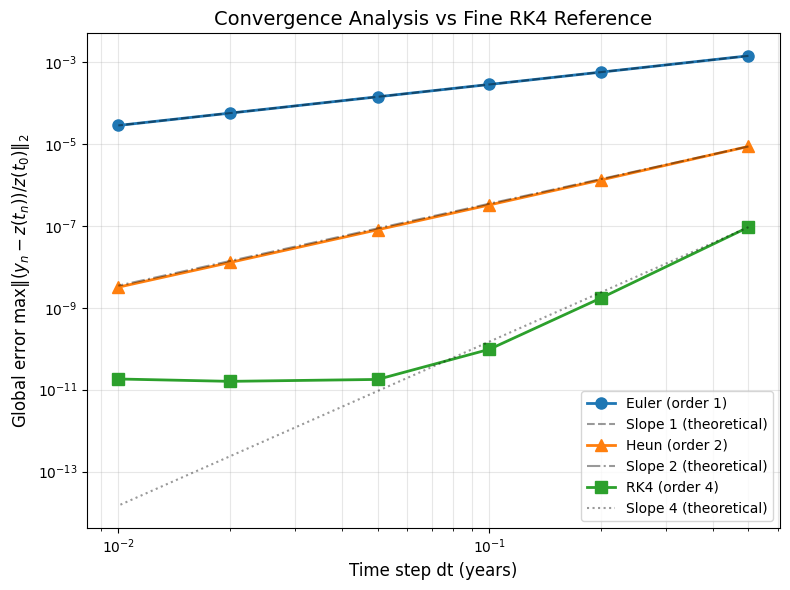

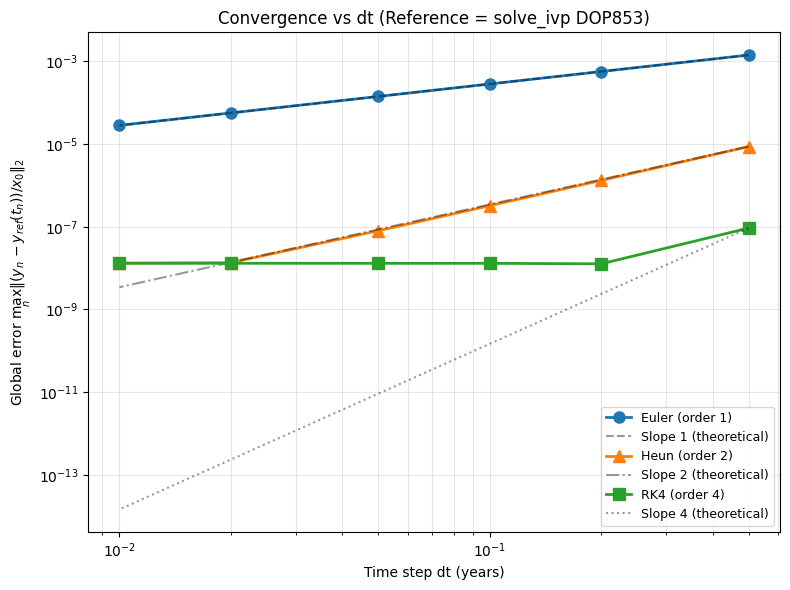

Computing reference solution for consistency (dt=0.0001)...


KeyboardInterrupt: 

In [8]:
def analyse_convergence():
    t0, tf = 1850, 2015 
    dt_ref = 0.0005
    
    print("Computing reference RK4 solution...")
    _, ref = run_rk4(x0, t0, tf, dt=dt_ref)

    dts = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01] 
    
    methods = {
        'Euler (order 1)': (run_euler,  'o-', 1),
        'Heun (order 2)':  (run_heun,   '^-', 2),
        'RK4 (order 4)':   (run_rk4,    's-', 4),
    }

    plt.figure(figsize=(8, 6))
    for label, (runner, style, order) in methods.items():
        errs = []
        for h in dts:
            _, res = runner(x0, t0, tf, h)
            step_ratio = int(round(h / dt_ref))
            ref_aligned = ref[::step_ratio] 
            
            diff = (res - ref_aligned) / x0
            norms_per_step = np.linalg.norm(diff, axis=1)
            max_global_error = np.max(norms_per_step)
            errs.append(max_global_error)
            
        plt.loglog(dts, errs, style, label=label, linewidth=2, markersize=8)
        
        ref_slope = errs[0] * (np.array(dts) / dts[0]) ** order
        plt.loglog(dts, ref_slope, 'k--' if order==1 else ('k-.' if order==2 else 'k:'),
                   alpha=0.4, linewidth=1.5, label=f'Slope {order} (theoretical)')

    plt.xlabel('Time step dt (years)', fontsize=12)
    plt.ylabel(r'Global error $\max \| (y_n - z(t_n)) / z(t_0) \|_2$', fontsize=12)
    plt.title('Convergence Analysis vs Fine RK4 Reference', fontsize=14)
    plt.legend(fontsize=10, loc='lower right') 
    plt.grid(alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()

def _solve_ivp_reference(t0, tf, t_eval, *, method="DOP853", rtol=1e-13, atol=1e-13):
    def f(t, y):
        return derivative(y, t)
    sol = solve_ivp(
        f, (t0, tf), x0,
        method=method,
        t_eval=t_eval,
        rtol=rtol, atol=atol,
        vectorized=False,
    )
    if not sol.success:
        raise RuntimeError(f"solve_ivp failed: {sol.message}")
    return sol.t, sol.y.T

def analyse_convergence_scipy():
    t0, tf = 1850.0, 2015.0
    dts = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01]

    scales = np.abs(x0).copy()
    scales[scales == 0] = 1.0

    methods = {
        "Euler (order 1)": (run_euler, "o-", 1),
        "Heun (order 2)":  (run_heun,  "^-", 2),
        "RK4 (order 4)":   (run_rk4,   "s-", 4),
    }

    plt.figure(figsize=(8, 6))

    for label, (runner, style, order) in methods.items():
        errs = []
        for h in dts:
            t_coarse = _make_times(t0, tf, h)
            _, ref = _solve_ivp_reference(
                t0, tf, t_eval=t_coarse,
                method="DOP853",
                rtol=1e-11, atol=1e-13
            )
            _, res = runner(x0, t0, tf, h)

            n = min(len(res), len(ref))
            diff = (res[:n] - ref[:n]) / scales
            norms = np.linalg.norm(diff, axis=1)
            errs.append(np.max(norms))

        plt.loglog(dts, errs, style, label=label, linewidth=2, markersize=8)
        ref_slope = errs[0] * (np.array(dts) / dts[0]) ** order
        plt.loglog(
            dts, ref_slope,
            "k--" if order == 1 else ("k-." if order == 2 else "k:"),
            alpha=0.4, linewidth=1.5,
            label=f"Slope {order} (theoretical)"
        )

    plt.xlabel("Time step dt (years)")
    plt.ylabel(r"Global error $\max_n \| (y_n - y_{ref}(t_n))/x_0 \|_2$")
    plt.title("Convergence vs dt (Reference = solve_ivp DOP853)")
    plt.legend(fontsize=9, loc="lower right")
    plt.grid(alpha=0.3, which="both")
    plt.tight_layout()
    plt.show()

def analyse_consistance():
    t0, tf = 1850.0, 2015.0
    dt_ultra_fine = 0.0001
    dts_coarse = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01]

    reservoir_idx = np.arange(7)
    reservoir_names = ['atm', 'rock', 'deep', 'fossil', 'plant', 'soil', 'surf']
    scales = np.abs(x0[reservoir_idx])
    scales[scales == 0] = 1.0

    print("Computing reference solution for consistency (dt=0.0001)...")
    _, z_ultra_fine = run_rk4(x0, t0, tf, dt=dt_ultra_fine)
    times_ultra_fine = np.arange(t0, tf + dt_ultra_fine, dt_ultra_fine)

    def _euler_step(x, t, h):
        return x + h * derivative(x, t)

    def _heun_step(x, t, h):
        k1 = derivative(x, t)
        k2 = derivative(x + h * k1, t + h)
        return x + h / 2 * (k1 + k2)

    methods = {
        'Euler': (_euler_step, 1),
        'Heun': (_heun_step, 2),
        'RK4': (_rk4_step, 4),
    }

    method_sum_by_h = {}
    for label, (step_fn, order) in methods.items():
        sums_for_h = []
        for h in dts_coarse:
            n_steps = int(round((tf - t0) / h))
            times_h = np.linspace(t0, tf, n_steps + 1)
            sum_norm_e = 0.0

            for n in range(len(times_h) - 1):
                tn = times_h[n]
                tnp1 = times_h[n + 1]
                h_actual = tnp1 - tn
                idx_n = np.argmin(np.abs(times_ultra_fine - tn))
                idx_np1 = np.argmin(np.abs(times_ultra_fine - tnp1))
                z_n_exact = z_ultra_fine[idx_n]
                z_np1_exact = z_ultra_fine[idx_np1]
                z_np1_scheme = step_fn(z_n_exact, tn, h_actual)
                e_n = z_np1_exact - z_np1_scheme
                e_rel = e_n[reservoir_idx] / scales
                sum_norm_e += np.linalg.norm(e_rel)

            sums_for_h.append(sum_norm_e)
        method_sum_by_h[label] = np.array(sums_for_h)

    plt.figure(figsize=(10, 6))
    styles = {'Euler': 'o-', 'Heun': 's-', 'RK4': '^-'}
    colors = {'Euler': 'C0', 'Heun': 'C1', 'RK4': 'C2'}
    slope_styles = {1: '--', 2: '-.', 4: ':'}
    
    for label, (_, order) in methods.items():
        vals = method_sum_by_h[label]
        plt.loglog(dts_coarse, vals, styles[label], color=colors[label], 
                   linewidth=2.5, markersize=9,
                   label=f'{label} (order {order})')
        if len(vals) > 1:
            h_ref, val_ref = dts_coarse[-1], vals[-1]
            ref_slope = val_ref * (np.array(dts_coarse) / h_ref) ** order
            plt.loglog(dts_coarse, ref_slope, slope_styles[order], 
                      color=colors[label], alpha=0.4, linewidth=1.5)

    plt.xlabel('Step size h (years)', fontsize=12)
    plt.ylabel(r'$\sum \|e_n\|$', fontsize=12)
    plt.title('Consistency Checking', fontsize=13)
    plt.grid(True, which='both', alpha=0.3)
    plt.legend(fontsize=10, loc='upper left')
    plt.tight_layout()
    plt.show()

def analyse_stability():
    t0, tf, dt = 1850, 2015, 0.1
    times = _make_times(t0, tf, dt)
    n_steps = len(times) - 1
    n_trials = 80
    method_name = 'RK4'
    state_dim = len(x0)
    delta0_size = 1e-6
    target_eps_norm = 1e-8
    eps_std = target_eps_norm / np.sqrt(state_dim)
    rng = np.random.default_rng(42)

    def run_pair(delta0, epsilons):
        y = np.zeros((n_steps + 1, len(x0)))
        y_pert = np.zeros((n_steps + 1, len(x0)))
        y[0] = x0
        y_pert[0] = x0 + delta0
        for n in range(n_steps):
            tn = times[n]
            y[n + 1] = _rk4_step(y[n], tn, dt)
            y_pert[n + 1] = _rk4_step(y_pert[n], tn, dt) + epsilons[n]
        return y, y_pert

    ratio_by_N = np.zeros(n_steps + 1)
    representative_lhs = None
    representative_rhs_base = None
    representative_ratio = -np.inf

    for _ in range(n_trials):
        delta0 = rng.normal(size=state_dim)
        delta0 /= np.linalg.norm(delta0)
        delta0 *= delta0_size
        epsilons = rng.normal(loc=0.0, scale=eps_std, size=(n_steps, state_dim))
        y, y_pert = run_pair(delta0, epsilons)
        diff_norms = np.linalg.norm(y_pert - y, axis=1)
        lhs_N = np.maximum.accumulate(diff_norms)
        epsilon_norms = np.linalg.norm(epsilons, axis=1)
        delta0_norm = np.linalg.norm(delta0)
        rhs_base_N = delta0_norm + np.concatenate(([0.0], np.cumsum(epsilon_norms)))
        ratios = np.divide(lhs_N, rhs_base_N, out=np.zeros_like(lhs_N), where=rhs_base_N > 0)
        ratio_by_N = np.maximum(ratio_by_N, ratios)
        trial_peak_ratio = np.max(ratios)
        if trial_peak_ratio > representative_ratio:
            representative_ratio = trial_peak_ratio
            representative_lhs = lhs_N.copy()
            representative_rhs_base = rhs_base_N.copy()

    stability_constant = np.max(ratio_by_N)
    representative_rhs = stability_constant * representative_rhs_base

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    N_values = np.arange(n_steps + 1)
    axes[0].plot(N_values, ratio_by_N, color='tab:blue', linewidth=2.5)
    axes[0].axhline(stability_constant, color='tab:red', linestyle='--', label=rf'$S \approx {stability_constant:.2f}$')
    axes[0].set(xlabel='Number of steps N', ylabel='Worst-case ratio', title='Theoretical Validation')
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(N_values, representative_lhs, color='tab:orange', label='LHS error norm')
    axes[1].plot(N_values, representative_rhs, color='tab:green', linestyle='--', label='RHS stability bound')
    axes[1].set(xlabel='Number of steps N', ylabel='Error terms', title='Left-hand side vs Bound')
    axes[1].grid(alpha=0.3)
    axes[1].legend()
    fig.suptitle('Stability Analysis', fontsize=14)
    plt.show()

analyse_convergence()
analyse_convergence_scipy()
analyse_consistance()
analyse_stability()

The convergence plots show that each method's error decreases according to its theoretical order.$\newline$
RK4 aligns closely with the $\mathcal{O}(h^4)$ slope, though at very small step sizes, the error reduction hits a floor due to floating-point machine precision.$\newline$
This validates our implementation against both a fine RK4 run and SciPy's solve_ivp.$\newline$
The consistency analysis verifies that the sum of the local truncation errors over the integration domain vanishes as $h \to 0$.$\newline$
Lastly, the stability tests show that injecting normal perturbations into the system does not cause exponential divergence.$\newline$
The ratio of accumulated error to the applied perturbations is bounded by a ceiling (the stability constant $S$), confirming the numerical integration remains stable over time.